In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set non-TensorFlow seeds
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# 3. Import TensorFlow and set its seed last
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

tf.random.set_seed(42)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

### DataSet

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2) 

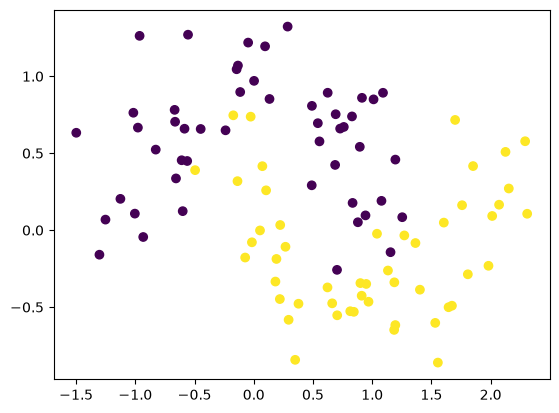

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

### He Initialization

In [7]:
model = Sequential([
    Dense(units=128, activation='sigmoid', input_dim=2, kernel_initializer="glorot_normal"), 
    Dense(units=1, activation="sigmoid")
])

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model.fit(X, y, epochs=50, validation_split = 0.2,verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.5375 - loss: 0.7521 - val_accuracy: 0.3500 - val_loss: 0.6896
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6750 - loss: 0.6418 - val_accuracy: 0.6500 - val_loss: 0.5743
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5875 - loss: 0.6421 - val_accuracy: 0.9000 - val_loss: 0.5550
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7250 - loss: 0.5923 - val_accuracy: 0.8000 - val_loss: 0.5753
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7375 - loss: 0.5622 - val_accuracy: 0.8000 - val_loss: 0.5358
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7375 - loss: 0.5274 - val_accuracy: 0.9000 - val_loss: 0.4590
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8000 - loss: 0.5057 - val_accuracy: 0.9000 - val_loss: 0.4116
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8000 - loss: 0.4949 - val_accuracy: 0.9000 - val_loss: 0.3905

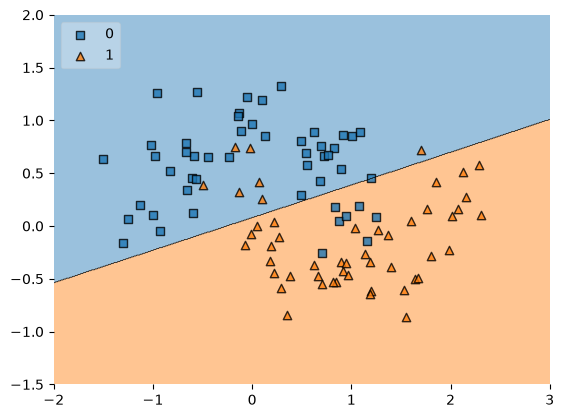

In [10]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

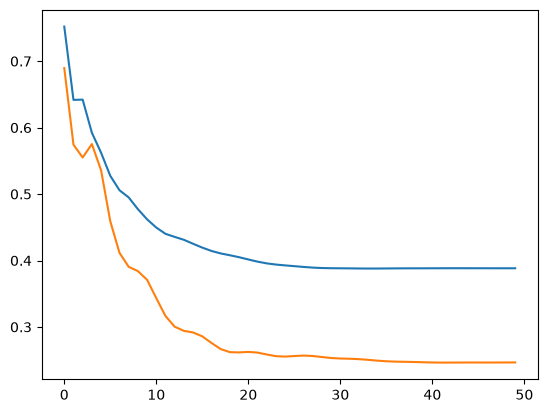

In [11]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])